In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.2 MB/s eta 0:00:00


In [2]:
!pip install supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 10.7 MB/s eta 0:00:00


In [3]:
import cv2
import time
from dataclasses import dataclass, field
from typing import Dict, List, Optional
import numpy as np



#  Tunable parameters
BASE_GREEN_SEC   = 20.0   # default green duration (seconds)
BASE_RED_SEC     = 15.0   # default red duration (seconds)
MIN_GREEN_SEC    = 8.0    # never go below this
MAX_GREEN_SEC    = 60.0   # cap to avoid starvation on other lanes
YELLOW_SEC       = 3.0    # fixed yellow phase

# How strongly each factor pulls the green time
DENSITY_WEIGHT   = 1.5    # extra seconds per vehicle above threshold
SPEED_VAR_WEIGHT = 0.4    # extra seconds per unit of speed std-dev
CONGESTION_BONUS = {"low": 0, "medium": 8, "high": 20}   # flat bonus (sec)

# Density thresholds (vehicles in lane)
LOW_DENSITY_THRESH    = 3
MEDIUM_DENSITY_THRESH = 7



#  Data structures
@dataclass
class LaneStats:
    """Per-lane snapshot passed in each frame."""
    lane_id: int
    vehicle_count: int          = 0
    avg_speed_kmh: float        = 0.0
    speed_std_kmh: float        = 0.0
    congestion_level: str       = "low"   # "low" | "medium" | "high"
    lane_crossing_count: int    = 0
    overspeed_count: int        = 0


@dataclass
class SignalPhase:
    """Represents one traffic light phase."""
    color: str          # "GREEN" | "YELLOW" | "RED"
    duration_sec: float
    elapsed_sec: float  = 0.0

    @property
    def remaining_sec(self) -> float:
        return max(0.0, self.duration_sec - self.elapsed_sec)

    @property
    def progress(self) -> float:
        """0.0 → 1.0 fraction of phase completed."""
        if self.duration_sec == 0:
            return 1.0
        return min(1.0, self.elapsed_sec / self.duration_sec)


@dataclass
class LaneSignalState:
    """Full signal state for one lane."""
    lane_id: int
    phase: SignalPhase = field(default_factory=lambda: SignalPhase("RED", BASE_RED_SEC))
    computed_green_sec: float = BASE_GREEN_SEC
    reason: str = ""            # human-readable explanation of last adjustment

    # Stats history (rolling)
    _density_history: List[int]   = field(default_factory=list)
    _speed_var_history: List[float] = field(default_factory=list)

    def update_history(self, stats: LaneStats, window: int = 30) -> None:
        self._density_history.append(stats.vehicle_count)
        self._speed_var_history.append(stats.speed_std_kmh)
        if len(self._density_history) > window:
            self._density_history.pop(0)
            self._speed_var_history.pop(0)

    @property
    def avg_density(self) -> float:
        return float(np.mean(self._density_history)) if self._density_history else 0.0

    @property
    def avg_speed_var(self) -> float:
        return float(np.mean(self._speed_var_history)) if self._speed_var_history else 0.0



#  Controller
class AdaptiveSignalController:

    def __init__(self, num_lanes: int, fps: float, cycle_offset_sec: float = 10.0):

        self.fps = fps
        self.num_lanes = num_lanes
        self.states: Dict[int, LaneSignalState] = {}

        for lane_id in range(num_lanes):
            state = LaneSignalState(lane_id=lane_id)
            # Stagger starting phase so lanes alternate naturally
            offset = lane_id * cycle_offset_sec
            if offset < BASE_GREEN_SEC:
                state.phase = SignalPhase("GREEN", BASE_GREEN_SEC, elapsed_sec=offset)
            else:
                state.phase = SignalPhase("RED",   BASE_RED_SEC,
                                          elapsed_sec=offset - BASE_GREEN_SEC)
            self.states[lane_id] = state

        self._last_frame: int = 0
        self._global_override: Optional[str] = None   # e.g. "EMERGENCY"

    # ── Public API

    def update(self, frame_idx: int, lane_stats: List[LaneStats]) -> None:

        dt = (frame_idx - self._last_frame) / self.fps   # seconds since last call
        self._last_frame = frame_idx

        stats_by_id = {s.lane_id: s for s in lane_stats}

        for lane_id, state in self.states.items():
            stats = stats_by_id.get(lane_id, LaneStats(lane_id=lane_id))
            state.update_history(stats)

            # Recompute desired green time for this lane
            state.computed_green_sec = self._compute_green(stats, state)

            # Advance phase clock
            state.phase.elapsed_sec += dt

            # Transition phases when time is up
            if state.phase.elapsed_sec >= state.phase.duration_sec:
                self._advance_phase(state)

    def get_display_status(self) -> Dict[int, dict]:

        out = {}
        for lane_id, state in self.states.items():
            phase = state.phase
            color_emoji = {"GREEN": "🟢", "YELLOW": "🟡", "RED": "🔴"}.get(phase.color, "⚪")
            out[lane_id] = {
                "color":     phase.color,
                "remaining": round(phase.remaining_sec, 1),
                "label":     f"{color_emoji} L{lane_id+1} {phase.color} — {phase.remaining_sec:.0f}s left",
                "reason":    state.reason,
                "progress":  phase.progress,
                "computed_green": round(state.computed_green_sec, 1),
            }
        return out

    def get_active_green_lanes(self) -> List[int]:
        """Returns list of lane_ids currently in GREEN phase."""
        return [lid for lid, s in self.states.items() if s.phase.color == "GREEN"]

    def force_green(self, lane_id: int, duration_sec: Optional[float] = None) -> None:
        """Emergency override — immediately give a lane a GREEN phase."""
        if lane_id in self.states:
            dur = duration_sec or self.states[lane_id].computed_green_sec
            self.states[lane_id].phase = SignalPhase("GREEN", dur)
            self.states[lane_id].reason = "FORCED GREEN (override)"

    # ── Internal helpers


    def _compute_green(self, stats: LaneStats, state: LaneSignalState) -> float:
        """
        Adaptive green time formula:

            green = BASE
                  + DENSITY_WEIGHT  * max(0, density - LOW_DENSITY_THRESH)
                  + SPEED_VAR_WEIGHT * speed_std
                  + CONGESTION_BONUS[level]

        Clamped to [MIN_GREEN_SEC, MAX_GREEN_SEC].
        """
        base = BASE_GREEN_SEC
        reasons = []

        # Density component
        density_excess = max(0, stats.vehicle_count - LOW_DENSITY_THRESH)
        density_add = DENSITY_WEIGHT * density_excess
        if density_add > 0:
            reasons.append(f"+{density_add:.0f}s density({stats.vehicle_count}v)")

        # Speed variation component (chaotic traffic → give more time to clear)
        var_add = SPEED_VAR_WEIGHT * stats.speed_std_kmh
        if var_add > 1:
            reasons.append(f"+{var_add:.0f}s spd-var")

        # Congestion level flat bonus
        cong_add = CONGESTION_BONUS.get(stats.congestion_level, 0)
        if cong_add > 0:
            reasons.append(f"+{cong_add}s {stats.congestion_level}-cong")

        green = base + density_add + var_add + cong_add
        green = float(np.clip(green, MIN_GREEN_SEC, MAX_GREEN_SEC))

        state.reason = ", ".join(reasons) if reasons else "nominal"
        return green

    def _advance_phase(self, state: LaneSignalState) -> None:
        """Cycle GREEN → YELLOW → RED → GREEN with adaptive durations."""
        current = state.phase.color
        overflow = state.phase.elapsed_sec - state.phase.duration_sec  # carry leftover

        if current == "GREEN":
            state.phase = SignalPhase("YELLOW", YELLOW_SEC, elapsed_sec=overflow)
        elif current == "YELLOW":
            state.phase = SignalPhase("RED",    BASE_RED_SEC, elapsed_sec=overflow)
        elif current == "RED":
            # Use the freshly computed adaptive green duration
            state.phase = SignalPhase("GREEN", state.computed_green_sec, elapsed_sec=overflow)



#  OpenCV overlay helper (optional)

SIGNAL_COLOR_BGR = {
    "GREEN":  (0,   200,  0),
    "YELLOW": (0,   200, 200),
    "RED":    (0,   0,   220),
}

def draw_signal_hud(frame, signal_status: dict, x: int = 0, y: int = 235) -> None:


    n = len(signal_status)
    panel_w, row_h = 310, 42
    panel_h = n * row_h + 28
    font = cv2.FONT_HERSHEY_SIMPLEX

    # Background
    overlay = frame.copy()
    cv2.rectangle(overlay, (x, y), (x + panel_w, y + panel_h), (10, 10, 10), -1)
    cv2.addWeighted(overlay, 0.50, frame, 0.50, 0, frame)

    # Header
    cv2.putText(frame, "ADAPTIVE SIGNAL STATUS", (x + 8, y + 17),
                font, 0.42, (180, 180, 180), 1, cv2.LINE_AA)
    cv2.line(frame, (x + 8, y + 22), (x + panel_w - 8, y + 22), (80, 80, 80), 1)

    for i, (lane_id, info) in enumerate(sorted(signal_status.items())):
        row_y = y + 28 + i * row_h
        color_bgr = SIGNAL_COLOR_BGR.get(info["color"], (150, 150, 150))

        # Colored circle indicator
        cv2.circle(frame, (x + 16, row_y + 14), 8, color_bgr, -1, cv2.LINE_AA)

        # Lane label + countdown
        main_text = f"Lane {lane_id+1}: {info['color']}  {info['remaining']:.0f}s"
        cv2.putText(frame, main_text, (x + 30, row_y + 18),
                    font, 0.46, color_bgr, 1, cv2.LINE_AA)

        # Progress bar
        bar_x1, bar_y  = x + 30, row_y + 25
        bar_w, bar_h   = panel_w - 45, 5
        cv2.rectangle(frame, (bar_x1, bar_y), (bar_x1 + bar_w, bar_y + bar_h),
                      (50, 50, 50), -1)
        filled = int(bar_w * (1.0 - info["progress"]))   # shrinks as phase progresses
        if filled > 0:
            cv2.rectangle(frame, (bar_x1, bar_y), (bar_x1 + filled, bar_y + bar_h),
                          color_bgr, -1)

        # Reason (small grey text)
        if info["reason"] and info["reason"] != "nominal":
            reason_short = info["reason"][:42]   # truncate for HUD width
            cv2.putText(frame, reason_short, (x + 30, row_y + 38),
                        font, 0.30, (130, 130, 130), 1, cv2.LINE_AA)




Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[INFO] Loading YOLO model...


100%|██████████| 1060/1060 [03:45<00:00,  4.69it/s]



[INFO] Writing summary CSV...

[INFO] Generating Plots from vehicle_speeds.csv...


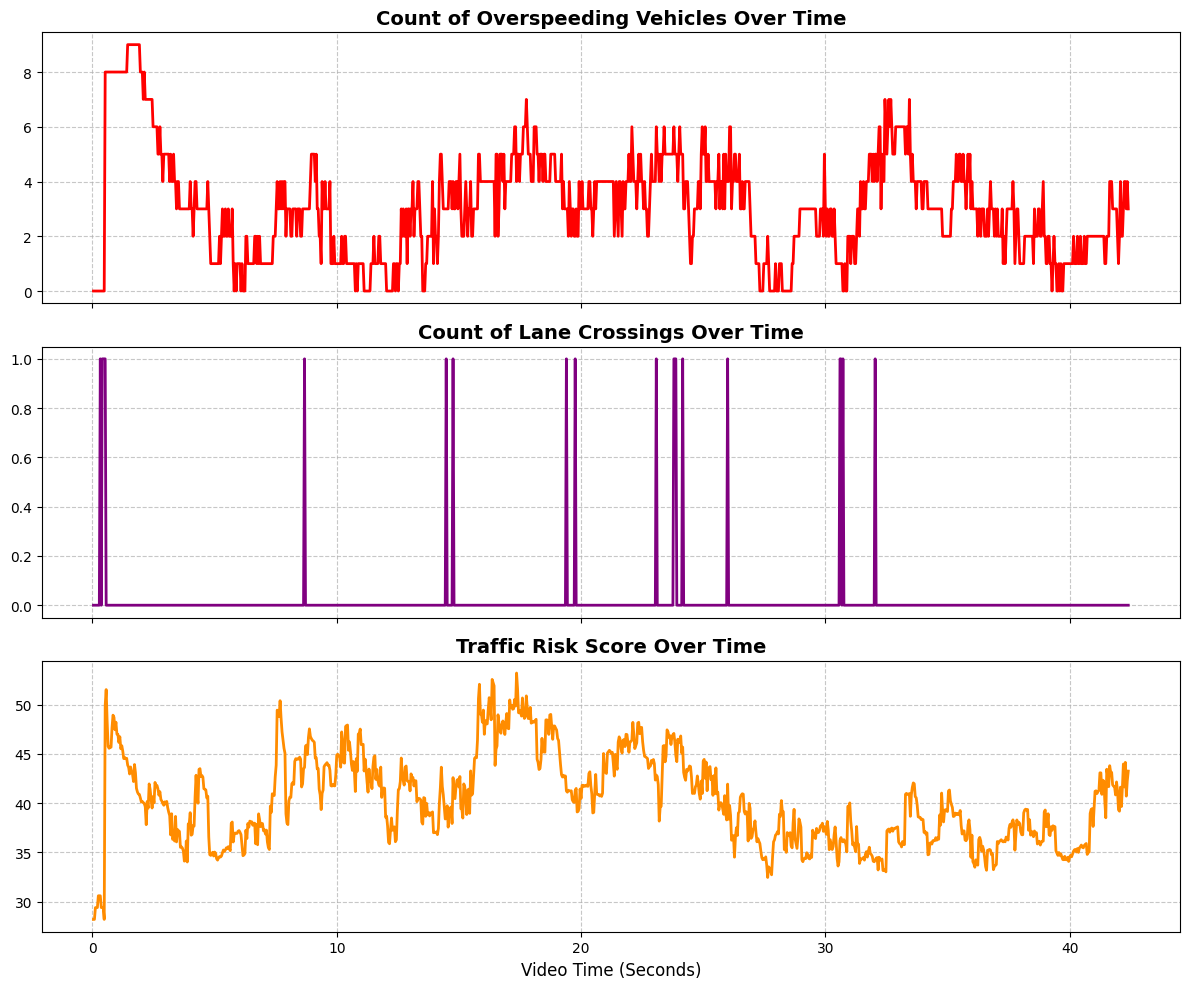

In [4]:
import cv2
import csv
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import supervision as sv
from tqdm import tqdm
from ultralytics import YOLO
from collections import defaultdict, deque


SOURCE_VIDEO_PATH = "traffic_surveillance_video.mp4"
TARGET_VIDEO_PATH = "output.mp4"
CSV_PER_FRAME = "vehicle_speeds.csv"
CSV_SUMMARY = "vehicle_speed_summary.csv"
CSV_FRAME_METRICS = "frame_metrics.csv"

CONFIDENCE_THRESHOLD = 0.3
IOU_THRESHOLD = 0.5
MODEL_NAME = "yolov8x.pt"
MODEL_RESOLUTION = 1280
SPEED_LIMIT = 60.0  # km/h
HIGH_DENSITY_THRESHOLD = 10  # Vehicles
CUSTOM_PALETTE = sv.ColorPalette.from_hex(['#00FF00', '#FF0000', '#FF00FF'])

# Risk & Congestion Parameters
CONGESTION_THRESHOLDS = {"low": 5, "medium": 10}
RISK_WEIGHTS = {"alpha": 1.2, "beta": 0.4, "gamma": 3.0}

TEXT_SCALE     = 0.4
TEXT_THICKNESS = 1
BOX_THICKNESS  = 2

# Colors (BGR for OpenCV)
COLOR_GREEN  = (0, 255, 0)
COLOR_RED    = (0, 0, 255)
COLOR_PURPLE = (255, 0, 255)

# Area for Speed Estimation (Perspective Transform)
SOURCE = np.array([
    [781, 216], [1056, 216], [1675, 530], [184, 482]
])
TARGET_WIDTH = 42
TARGET_HEIGHT = 210
TARGET = np.array([
    [0, 0], [TARGET_WIDTH - 1, 0],
    [TARGET_WIDTH - 1, TARGET_HEIGHT - 1], [0, TARGET_HEIGHT - 1],
])

# --- Manually Defined Lane Polygons ---
LANE_POLYGONS = [
    np.array([[48, 634], [801, 240], [828, 246], [137, 744]], dtype=np.int32),
    np.array([[137, 744], [828, 244], [861, 254], [312, 870]], dtype=np.int32),
    np.array([[313, 867], [864, 253], [899, 257], [643, 914]], dtype=np.int32),
    np.array([[1168, 899], [957, 254], [993, 252], [1465, 866]], dtype=np.int32),
    np.array([[1465, 866], [995, 252], [1031, 254], [1714, 836]], dtype=np.int32),
    np.array([[1714, 836], [1034, 253], [1068, 257], [1859, 751]], dtype=np.int32),
]



class ViewTransformer:
    def __init__(self, source: np.ndarray, target: np.ndarray) -> None:
        source = source.astype(np.float32)
        target = target.astype(np.float32)
        self.m = cv2.getPerspectiveTransform(source, target)

    def transform_points(self, points: np.ndarray) -> np.ndarray:
        if points.size == 0:
            return points
        reshaped = points.reshape(-1, 1, 2).astype(np.float32)
        transformed = cv2.perspectiveTransform(reshaped, self.m)
        return transformed.reshape(-1, 2)


def draw_semi_transparent_box(frame, x1, y1, x2, y2, color=(10, 10, 10), alpha=0.45):
    overlay = frame.copy()
    cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)
    cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0, frame)


def draw_warning_banner(frame, text: str, vh: int, vw: int, color=(0, 0, 160), y_offset=55):
    banner_y = vh - y_offset
    draw_semi_transparent_box(frame, 0, banner_y, vw, banner_y + 55, color, 0.60)
    (tw, _), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_DUPLEX, 0.82, 2)
    tx, ty = (vw - tw) // 2, banner_y + 36
    cv2.putText(frame, text, (tx + 2, ty + 2), cv2.FONT_HERSHEY_DUPLEX, 0.82, (0, 0, 0), 2)
    cv2.putText(frame, text, (tx, ty),         cv2.FONT_HERSHEY_DUPLEX, 0.82, (255, 255, 255), 2)


def plot_traffic_data(csv_path):
    print(f"\n[INFO] Generating Plots from {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"[ERROR] Could not find {csv_path} to generate plots.")
        return

    frame_data = df.groupby('timestamp_sec').agg({
        'overspeed_flag':    'sum',
        'lane_crossing_flag':'sum',
        'risk_score':        'mean'
    }).reset_index()

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.canvas.manager.set_window_title('Traffic Surveillance Metrics')

    axes[0].plot(frame_data['timestamp_sec'], frame_data['overspeed_flag'], color='red', linewidth=2)
    axes[0].set_title('Count of Overspeeding Vehicles Over Time', fontsize=14, fontweight='bold')
    axes[0].grid(True, linestyle='--', alpha=0.7)

    axes[1].plot(frame_data['timestamp_sec'], frame_data['lane_crossing_flag'], color='purple', linewidth=2)
    axes[1].set_title('Count of Lane Crossings Over Time', fontsize=14, fontweight='bold')
    axes[1].grid(True, linestyle='--', alpha=0.7)

    axes[2].plot(frame_data['timestamp_sec'], frame_data['risk_score'], color='darkorange', linewidth=2)
    axes[2].set_title('Traffic Risk Score Over Time', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Video Time (Seconds)', fontsize=12)
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()



# --- Main Logic ---
if __name__ == '__main__':
    print("[INFO] Loading YOLO model...")
    model            = YOLO(MODEL_NAME)
    view_transformer = ViewTransformer(source=SOURCE, target=TARGET)
    video_info       = sv.VideoInfo.from_video_path(video_path=SOURCE_VIDEO_PATH)


    lane_polygons = LANE_POLYGONS

    # --- Instantiate Adaptive Signal Controller ---
    signal_controller = AdaptiveSignalController(
        num_lanes=max(1, len(lane_polygons)),
        fps=video_info.fps,
    )

    # Initialize Trackers and Annotators
    byte_track    = sv.ByteTrack(frame_rate=video_info.fps, track_activation_threshold=CONFIDENCE_THRESHOLD)
    polygon_zone  = sv.PolygonZone(polygon=SOURCE)

    bounding_box_annotator = sv.BoxAnnotator(
        color=CUSTOM_PALETTE, color_lookup=sv.ColorLookup.CLASS, thickness=BOX_THICKNESS)
    trace_annotator = sv.TraceAnnotator(
        color=CUSTOM_PALETTE, color_lookup=sv.ColorLookup.CLASS, thickness=BOX_THICKNESS,
        trace_length=video_info.fps * 2, position=sv.Position.BOTTOM_CENTER)

    # Data Structures
    coordinates          = defaultdict(lambda: deque(maxlen=int(video_info.fps)))
    unique_vehicles      = set()
    track_current_lane   = {}
    track_lane_crossings = defaultdict(int)
    track_lane_cross_timer = defaultdict(int)
    track_all_speeds     = defaultdict(list)
    track_classes        = {}
    track_first_frame    = {}
    track_last_frame     = {}

    HISTORY_WINDOW_SEC = 10
    PREDICTION_HORIZON_SEC = 5
    global_density_history = deque(maxlen=int(video_info.fps * HISTORY_WINDOW_SEC))
    global_risk_history = deque(maxlen=int(video_info.fps * HISTORY_WINDOW_SEC))

    lane_cross_banner_frames = 0
    frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)

    # Open CSVs and Video Sink
    with open(CSV_PER_FRAME, "w", newline="") as f_frame, \
         open(CSV_FRAME_METRICS, "w", newline="") as f_metrics, \
         sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:

        w_frame = csv.writer(f_frame)
        w_frame.writerow([
            "frame", "timestamp_sec", "track_id", "vehicle_class",
            "speed_kmh", "overspeed_flag", "lane_crossing_flag", "risk_score"
        ])

        w_metrics = csv.writer(f_metrics)
        w_metrics.writerow([
            "frame", "timestamp_sec", "live_vehicles",
            "pred_vehicles_5s",
            "overspeeding_vehicles", "lane_crossings",
            "speed_variation", "risk_score", "pred_risk_score_5s"
        ])

        for frame_idx, frame in tqdm(enumerate(frame_generator, start=1), total=video_info.total_frames):
            ts     = frame_idx / video_info.fps
            result = model(frame, imgsz=MODEL_RESOLUTION, verbose=False)[0]
            detections = sv.Detections.from_ultralytics(result)

            # Filter detections
            detections = detections[detections.confidence > CONFIDENCE_THRESHOLD]
            valid_classes = [2, 3, 5, 7]  # Cars, Motorcycles, Buses, Trucks
            detections = detections[np.isin(detections.class_id, valid_classes)]
            detections = detections[polygon_zone.trigger(detections)]
            detections = detections.with_nms(IOU_THRESHOLD)
            detections = byte_track.update_with_detections(detections=detections)

            unique_vehicles.update(detections.tracker_id)

            points    = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)
            rw_points = view_transformer.transform_points(points=points).astype(int)

            current_frame_speeds = []
            overspeeding_now     = set()
            lane_crossing_now    = set()
            custom_labels_data   = []
            color_indices        = []

            # Per-vehicle analysis
            for i in range(len(detections)):
                tracker_id = detections.tracker_id[i]
                class_id   = detections.class_id[i]
                bbox       = detections.xyxy[i]
                orig_cx    = int((bbox[0] + bbox[2]) // 2)
                orig_cy    = int(bbox[3])
                class_name = result.names[class_id].capitalize()

                track_classes[tracker_id] = class_name
                track_first_frame.setdefault(tracker_id, frame_idx)
                track_last_frame[tracker_id] = frame_idx

                # 1. Lane Crossing Logic
                current_lane_idx = -1
                for j, poly in enumerate(lane_polygons):
                    if cv2.pointPolygonTest(poly, (orig_cx, orig_cy), False) >= 0:
                        current_lane_idx = j
                        break

                if current_lane_idx != -1:
                    if tracker_id in track_current_lane and track_current_lane[tracker_id] != current_lane_idx:
                        lane_crossing_now.add(tracker_id)
                        track_lane_crossings[tracker_id] += 1
                        track_lane_cross_timer[tracker_id] = int(video_info.fps * 1.0)
                    track_current_lane[tracker_id] = current_lane_idx

                is_displaying_lane_cross = track_lane_cross_timer[tracker_id] > 0

                # 2. Speed Logic
                coordinates[tracker_id].append(rw_points[i][1])
                speed = 0.0
                if len(coordinates[tracker_id]) >= video_info.fps / 2:
                    dist         = abs(coordinates[tracker_id][-1] - coordinates[tracker_id][0])
                    time_elapsed = len(coordinates[tracker_id]) / video_info.fps
                    speed        = (dist / time_elapsed) * 3.6

                current_frame_speeds.append(speed)
                track_all_speeds[tracker_id].append(speed)

                is_overspeed = speed > SPEED_LIMIT
                if is_overspeed:
                    overspeeding_now.add(tracker_id)

                # 3. Color priority: Lane Cross > Overspeed > Normal
                if is_displaying_lane_cross:
                    speed_text, color_idx, draw_color = f"{int(speed)} km/h", 2, COLOR_PURPLE
                    track_lane_cross_timer[tracker_id] -= 1
                elif is_overspeed:
                    speed_text, color_idx, draw_color = f"{int(speed)} km/h", 1, COLOR_RED
                else:
                    speed_text  = f"{int(speed)} km/h" if speed > 0 else "Calc..."
                    color_idx, draw_color = 0, COLOR_GREEN

                color_indices.append(color_idx)
                custom_labels_data.append((bbox, class_name, speed_text, draw_color))

            if len(detections) > 0:
                detections.class_id = np.array(color_indices)

            # 4. Risk, Congestion & Trend Prediction Calculation
            active_tracks = len(detections)
            global_density_history.append(active_tracks) # Store history

            if active_tracks < CONGESTION_THRESHOLDS["low"]:
                cong_str, c_val, cong_color = "Low",    1, COLOR_GREEN
            elif active_tracks < CONGESTION_THRESHOLDS["medium"]:
                cong_str, c_val, cong_color = "Medium", 2, (0, 165, 255)
            else:
                cong_str, c_val, cong_color = "High",   3, COLOR_RED

            speed_var  = np.std(current_frame_speeds) if len(current_frame_speeds) > 1 else 0.0
            risk_score = (RISK_WEIGHTS["alpha"] * active_tracks +
                          RISK_WEIGHTS["beta"]  * speed_var     +
                          RISK_WEIGHTS["gamma"] * c_val)

            global_risk_history.append(risk_score)

            # TREND PREDICTION LOGIC
            predicted_density = active_tracks  # Default fallback
            pred_cong_str = cong_str
            pred_cong_color = cong_color

            # Only predict if we have at least 3 seconds of data to form a trend line
            if len(global_density_history) > int(video_info.fps * 3):
                y_data = list(global_density_history)
                x_data = np.arange(len(y_data))

                # Fit a 1st-degree polynomial (Linear Regression: y = mx + c)
                m, c = np.polyfit(x_data, y_data, 1)

                # Predict X frames into the future
                future_x = len(y_data) + int(video_info.fps * PREDICTION_HORIZON_SEC)
                predicted_density = int(m * future_x + c)
                predicted_density = max(0, predicted_density) # Prevent negative predictions

                # Classify future congestion
                if predicted_density < CONGESTION_THRESHOLDS["low"]:
                    pred_cong_str, pred_cong_color = "Low", COLOR_GREEN
                elif predicted_density < CONGESTION_THRESHOLDS["medium"]:
                    pred_cong_str, pred_cong_color = "Medium", (0, 165, 255)
                else:
                    pred_cong_str, pred_cong_color = "High", COLOR_RED

            predicted_risk = risk_score
            risk_trend = "Stable"

            if len(global_risk_history) > int(video_info.fps * 3):
                y_risk = list(global_risk_history)
                x_risk = np.arange(len(y_risk))

                # Fit a 1st-degree polynomial (y = mx + c) to historical risk
                m_risk, c_risk = np.polyfit(x_risk, y_risk, 1)

                # Predict risk at future frame
                future_frame = len(y_risk) + int(video_info.fps * PREDICTION_HORIZON_SEC)
                predicted_risk = max(0, float(m_risk * future_frame + c_risk))

                # Determine Trend
                if predicted_risk > risk_score + 1.0:
                    risk_trend = "Increasing"
                elif predicted_risk < risk_score - 1.0:
                    risk_trend = "Decreasing"
                else:
                    risk_trend = "Stable"


            # 5. Write per-frame CSV
            for i in range(len(detections)):
                t_id = detections.tracker_id[i]
                w_frame.writerow([
                    frame_idx, round(ts, 3), t_id, track_classes[t_id],
                    round(current_frame_speeds[i], 1),
                    int(t_id in overspeeding_now),
                    int(t_id in lane_crossing_now),
                    round(risk_score, 2)
                ])

            # Adaptive Signal Update
            lane_stats_list = []
            for lane_idx, poly in enumerate(lane_polygons):
                lane_vehicle_speeds  = []
                lane_overspeed_count = 0
                lane_cross_count     = 0

                for i in range(len(detections)):
                    t_id = detections.tracker_id[i]
                    bbox = detections.xyxy[i]
                    cx   = int((bbox[0] + bbox[2]) // 2)
                    cy   = int(bbox[3])
                    if cv2.pointPolygonTest(poly, (cx, cy), False) >= 0:
                        lane_vehicle_speeds.append(current_frame_speeds[i])
                        if t_id in overspeeding_now:
                            lane_overspeed_count += 1
                        if t_id in lane_crossing_now:
                            lane_cross_count += 1

                n_in_lane  = len(lane_vehicle_speeds)
                avg_spd_ln = float(np.mean(lane_vehicle_speeds)) if n_in_lane else 0.0
                std_spd_ln = float(np.std(lane_vehicle_speeds))  if n_in_lane > 1 else 0.0

                if n_in_lane < CONGESTION_THRESHOLDS["low"]:
                    ln_cong = "low"
                elif n_in_lane < CONGESTION_THRESHOLDS["medium"]:
                    ln_cong = "medium"
                else:
                    ln_cong = "high"

                lane_stats_list.append(LaneStats(
                    lane_id             = lane_idx,
                    vehicle_count       = n_in_lane,
                    avg_speed_kmh       = avg_spd_ln,
                    speed_std_kmh       = std_spd_ln,
                    congestion_level    = ln_cong,
                    lane_crossing_count = lane_cross_count,
                    overspeed_count     = lane_overspeed_count,
                ))

            # Fallback: no lanes drawn → use global stats
            if not lane_stats_list:
                lane_stats_list.append(LaneStats(
                    lane_id=0,
                    vehicle_count    = active_tracks,
                    avg_speed_kmh    = float(np.mean(current_frame_speeds)) if current_frame_speeds else 0.0,
                    speed_std_kmh    = float(np.std(current_frame_speeds))  if len(current_frame_speeds) > 1 else 0.0,
                    congestion_level = cong_str.lower(),
                ))

            signal_controller.update(frame_idx, lane_stats_list)
            signal_status = signal_controller.get_display_status()

            # Emergency override: force green for the most congested lane if it's stuck on red
            if lane_stats_list:
                heaviest = max(lane_stats_list, key=lambda s: s.vehicle_count)
                if (heaviest.congestion_level == "high"
                        and signal_status.get(heaviest.lane_id, {}).get("color") == "RED"):
                    signal_controller.force_green(heaviest.lane_id)
                    signal_status = signal_controller.get_display_status()  # refresh after override


            # --- Drawing & Annotation ---
            annotated_frame = frame.copy()

            # Draw user lanes
            for j, poly in enumerate(lane_polygons):
                cv2.polylines(annotated_frame, [poly], isClosed=True,
                              color=(255, 255, 255), thickness=1, lineType=cv2.LINE_AA)
                cv2.putText(annotated_frame, f"L{j+1}", tuple(poly[0]),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

            # Supervision traces & boxes
            annotated_frame = trace_annotator.annotate(scene=annotated_frame, detections=detections)
            annotated_frame = bounding_box_annotator.annotate(scene=annotated_frame, detections=detections)

            # Custom vehicle labels
            font = cv2.FONT_HERSHEY_SIMPLEX
            for bbox, c_name, s_text, s_color in custom_labels_data:
                x1, y1, x2, y2 = bbox
                (w1, h1), _ = cv2.getTextSize(c_name,  font, TEXT_SCALE, TEXT_THICKNESS)
                (w2, h2), _ = cv2.getTextSize(s_text,  font, TEXT_SCALE, TEXT_THICKNESS)
                box_width  = max(w1, w2) + 10
                box_height = h1 + h2 + 15
                label_x    = int(x1)
                label_y    = int(y1) - box_height if int(y1) - box_height > 0 else int(y1)
                cv2.rectangle(annotated_frame,
                              (label_x, label_y),
                              (label_x + box_width, label_y + box_height), (0, 0, 0), -1)
                cv2.putText(annotated_frame, c_name,
                            (label_x + 5, label_y + h1 + 5),
                            font, TEXT_SCALE, (255, 255, 255), TEXT_THICKNESS, cv2.LINE_AA)
                cv2.putText(annotated_frame, s_text,
                            (label_x + 5, label_y + h1 + h2 + 10),
                            font, TEXT_SCALE, s_color, TEXT_THICKNESS, cv2.LINE_AA)

            # Stats HUD
            draw_semi_transparent_box(annotated_frame, 0, 0, 310, 280)
            cv2.putText(annotated_frame, "TRAFFIC MONITOR & RISK", (8, 20),
                        font, 0.48, (200, 200, 200), 1)
            cv2.line(annotated_frame, (8, 26), (302, 26), (100, 100, 100), 1)
            cv2.putText(annotated_frame, f"Live Vehicles: {active_tracks} | Total: {len(unique_vehicles)}",
                        (8, 50), font, 0.50, (255, 255, 255), 1)
            cv2.putText(annotated_frame, f"Congestion   : {cong_str}",
                        (8, 75), font, 0.50, cong_color, 1)
            cv2.putText(annotated_frame, f"Risk Score   : {risk_score:.1f}",
                        (8, 100), cv2.FONT_HERSHEY_DUPLEX, 0.55, (0, 120, 255), 1)

            n_over = len(overspeeding_now)
            n_lane = len(lane_crossing_now)

            w_metrics.writerow([
                frame_idx,
                round(ts, 3),
                active_tracks,
                predicted_density,
                n_over,
                n_lane,
                round(speed_var, 3),
                round(risk_score, 3),
                round(predicted_risk, 3)
            ])

            cv2.putText(annotated_frame, f"Overspeeding : {n_over}",
                        (8, 135), font, 0.50, COLOR_RED if n_over > 0 else (180, 180, 180), 1)
            cv2.putText(annotated_frame, f"Lane Crosses : {n_lane}",
                        (8, 160), font, 0.50, COLOR_PURPLE if n_lane > 0 else (180, 180, 180), 1)

            # --- ADD PREDICTION DISPLAY ---
            cv2.putText(annotated_frame, f"Pred Density : {predicted_density} (+{PREDICTION_HORIZON_SEC}s)",
                        (8, 195), font, 0.50, (255, 255, 255), 1)
            cv2.putText(annotated_frame, f"Pred Congest : {pred_cong_str}",
                        (8, 220), font, 0.50, pred_cong_color, 1)
            cv2.putText(annotated_frame, f"Risk Trend   : {risk_trend}",
                        (8, 120), cv2.FONT_HERSHEY_DUPLEX, 0.50, (255, 255, 255), 1)
            cv2.putText(annotated_frame, f"Pred Risk    : {predicted_risk:.1f}",
                        (8, 245), font, 0.50, (0, 120, 255), 1)

            # Legend (Pushed down from Y=200 to Y=255)
            cv2.circle(annotated_frame, (10,  255), 5, COLOR_GREEN,  -1)
            cv2.putText(annotated_frame, "Norm", (18,  259), font, 0.38, COLOR_GREEN,  1)
            cv2.circle(annotated_frame, (75,  255), 5, COLOR_RED,   -1)
            cv2.putText(annotated_frame, "Spd",  (83,  259), font, 0.38, COLOR_RED,   1)
            cv2.circle(annotated_frame, (130, 255), 5, COLOR_PURPLE, -1)
            cv2.putText(annotated_frame, "Lane", (138, 259), font, 0.38, COLOR_PURPLE, 1)

            # Adaptive Signal HUD (Pushed down from Y=235 to Y=285)
            draw_signal_hud(annotated_frame, signal_status, x=0, y=285)

            # Warning banners
            vw, vh = video_info.resolution_wh
            if active_tracks > HIGH_DENSITY_THRESHOLD:
                draw_warning_banner(annotated_frame,
                                    f"!! HIGH DENSITY — {active_tracks} VEHICLES !!",
                                    vh, vw, color=(0, 100, 255), y_offset=235)
            if n_over > 0:
                draw_warning_banner(annotated_frame,
                                    f"!! OVERSPEED ALERT — {n_over} VEHICLE(S) !!",
                                    vh, vw, color=(0, 0, 160), y_offset=175)

            if n_lane > 0:
                lane_cross_banner_frames = int(video_info.fps * 1.0)
            if lane_cross_banner_frames > 0:
                draw_warning_banner(annotated_frame,
                                    "!! ILLEGAL LANE CROSSING !!",
                                    vh, vw, color=(160, 0, 160), y_offset=115)
                lane_cross_banner_frames -= 1

            sink.write_frame(annotated_frame)

    # --- Post-Processing (Summary CSV & Plots) ---
    print("\n[INFO] Writing summary CSV...")
    with open(CSV_SUMMARY, "w", newline="") as sf:
        sw = csv.writer(sf)
        sw.writerow([
            "track_id", "vehicle_class", "first_frame", "last_frame",
            "max_speed_kmh", "avg_speed_kmh", "overspeed_flag", "total_lane_crossings"
        ])
        for tid in sorted(track_all_speeds.keys()):
            speeds = [s for s in track_all_speeds[tid] if s > 0]
            if not speeds:
                continue
            max_spd, avg_spd = max(speeds), sum(speeds) / len(speeds)
            sw.writerow([
                tid, track_classes.get(tid, "Unknown"),
                track_first_frame.get(tid, ""), track_last_frame.get(tid, ""),
                round(max_spd, 2), round(avg_spd, 2),
                int(max_spd > SPEED_LIMIT), track_lane_crossings.get(tid, 0)
            ])

    plot_traffic_data(CSV_PER_FRAME)
